<a href="https://colab.research.google.com/github/saverin0/Advanced_Geospatial_Analysis/blob/main/03_geoviz_foundational_tech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 · Geo-visualisation foundations: vector and raster

Two publication-style maps:

1. **Vector** - a log-scaled world GDP choropleth from Natural Earth on a dark CartoDB basemap.
2. **Raster** - the SRTM digital terrain model of Germany, clipped to the country outline and
   reprojected to Web Mercator (EPSG:3857).

Basemap tiles are fetched with `contextily`, so an internet connection is required.

In [ ]:
%pip install -q contextily

In [ ]:
import io, os, math, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.plot import plotting_extent

DATA = Path("data")
DATA.mkdir(exist_ok=True)
FIG = Path("figures")
FIG.mkdir(exist_ok=True)


def read_preview(path, max_px=2000):
    """Read band 1 decimated so the longer side is <= max_px. Use this for plotting:
    imshow on the full 142-megapixel array needs several GB and kills small kernels."""
    with rasterio.open(path) as src:
        f = max(1, math.ceil(max(src.width, src.height) / max_px))
        arr = src.read(1, out_shape=(src.height // f, src.width // f),
                       resampling=Resampling.average, masked=True)
        return arr, plotting_extent(src)


def download(url, dest, unzip=False):
    """Download `url` to `dest` (file, or folder when unzip=True). Skips if already present."""
    dest = Path(dest)
    if dest.is_file() or (dest.is_dir() and any(dest.iterdir())):
        print("already present:", dest)
        return dest
    print("downloading:", url)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=600) as r:
        payload = r.read()
    if unzip:
        dest.mkdir(parents=True, exist_ok=True)
        zipfile.ZipFile(io.BytesIO(payload)).extractall(dest)
    else:
        dest.write_bytes(payload)
    print(f"saved: {dest}  ({len(payload) / 1e6:.1f} MB)")
    return dest

from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatter
import contextily as ctx

### Basemap providers

CartoDB (Positron, Dark Matter) tiles now require an API key, so `contextily` prints a warning and
CARTO watermarks the tiles. Esri's Canvas tiles are still free without a key and give a similar
clean look, so this notebook defines them explicitly. `requires_token()` tells you whether a
provider needs a key.

In [ ]:
from xyzservices import TileProvider

ESRI_CANVAS = "https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/{layer}/MapServer/tile/{{z}}/{{y}}/{{x}}"
ESRI_ATTR = "Tiles (c) Esri - Esri, HERE, Garmin, (c) OpenStreetMap contributors, and the GIS User Community"

def esri_canvas(layer, name):
    return TileProvider(name=name, url=ESRI_CANVAS.format(layer=layer), attribution=ESRI_ATTR, max_zoom=16)

DARK_BASE = esri_canvas("World_Dark_Gray_Base", "Esri.WorldDarkGrayBase")
DARK_LABELS = esri_canvas("World_Dark_Gray_Reference", "Esri.WorldDarkGrayReference")
LIGHT_BASE = ctx.providers.Esri.WorldGrayCanvas
LIGHT_LABELS = esri_canvas("World_Light_Gray_Reference", "Esri.WorldLightGrayReference")

for p in (ctx.providers.CartoDB.Positron, ctx.providers.OpenStreetMap.Mapnik, LIGHT_BASE, DARK_BASE):
    print(f"{p.name:28s} requires_token = {p.requires_token()}")

CartoDB.Positron             requires_token = True
OpenStreetMap.Mapnik         requires_token = False
Esri.WorldGrayCanvas         requires_token = False
Esri.WorldDarkGrayBase       requires_token = False


## Vector: Natural Earth countries

In [ ]:
NE_URL = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
download(NE_URL, DATA / "ne_countries", unzip=True)

gdf = gpd.read_file(next((DATA / "ne_countries").rglob("*.shp")))
gdf = gdf[["ADMIN", "POP_EST", "GDP_MD", "geometry"]]
gdf.head(3)

already present: data\ne_countries


,ADMIN,POP_EST,GDP_MD,geometry
0,Indonesia,270625568.0,1119190,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Malaysia,31949777.0,364681,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Chile,18952038.0,282318,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."


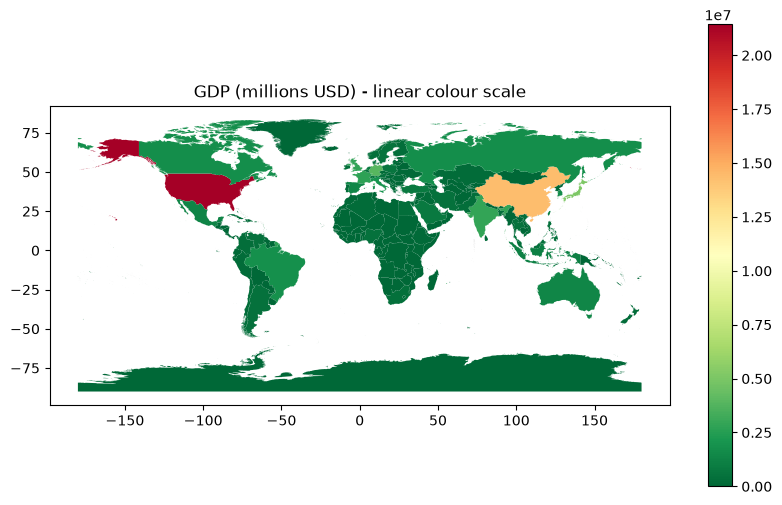

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
gdf.plot(ax=ax, column="GDP_MD", cmap="RdYlGn_r", legend=True)
ax.set_title("GDP (millions USD) - linear colour scale")
plt.show()

A linear scale is dominated by a handful of large economies. A log scale spreads the colours out.

In [ ]:
gdf = gdf[gdf.ADMIN != "Antarctica"].copy()
gdf["GDP_MD"] = pd.to_numeric(gdf["GDP_MD"], errors="coerce")
pos = gdf.loc[gdf["GDP_MD"] > 0, "GDP_MD"]
norm = LogNorm(vmin=pos.quantile(0.02), vmax=pos.quantile(0.98))

gdf_3857 = gdf.to_crs(3857)

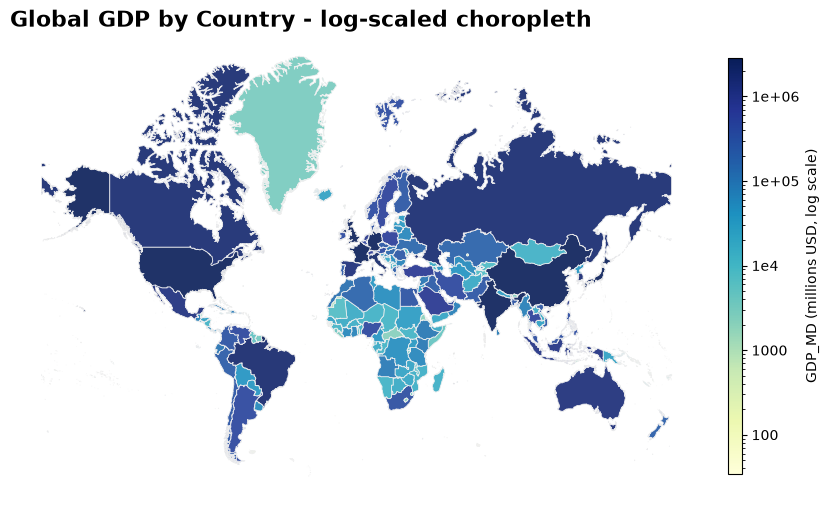

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
for s in ax.spines.values():
    s.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])

gdf_3857.plot(
    ax=ax, column="GDP_MD", cmap="YlGnBu", norm=norm, alpha=0.9,
    edgecolor="#f0f0f0", linewidth=0.6, zorder=2, legend=True,
    legend_kwds={"label": "GDP_MD (millions USD, log scale)", "shrink": 0.9, "pad": 0.02, "aspect": 30,
                 "ticks": LogLocator(base=10, subs=(1.0,)), "format": LogFormatter(10, labelOnlyBase=False)},
    missing_kwds={"color": "#4a4a4a", "edgecolor": "#bfbfbf", "hatch": "///", "label": "No data"},
)
ax.set_title("Global GDP by Country - log-scaled choropleth", loc="left", fontsize=16, weight="bold")
plt.show()

### Dark-themed version with a basemap

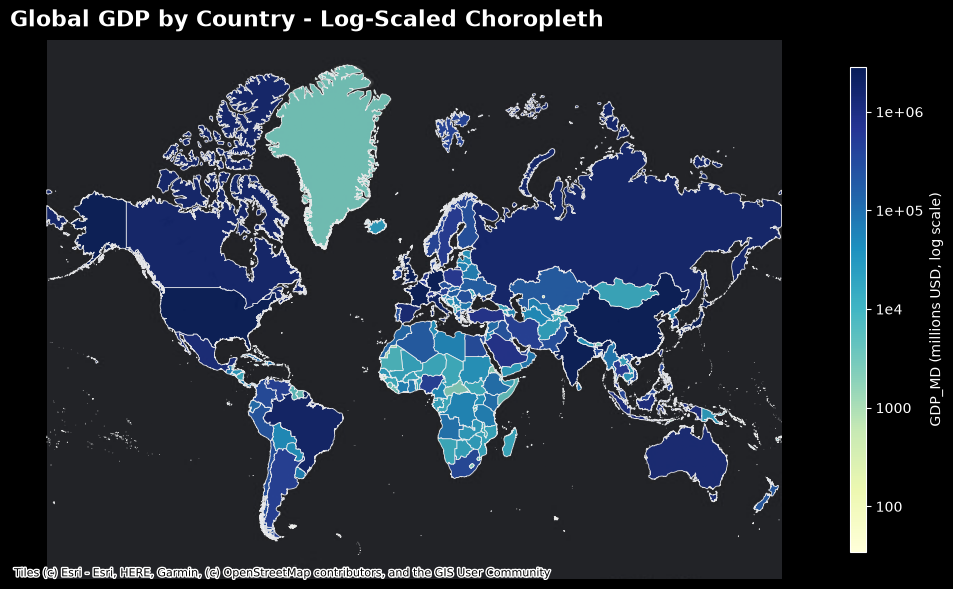

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")
for s in ax.spines.values():
    s.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])

gdf_3857.plot(
    ax=ax, column="GDP_MD", cmap="YlGnBu", norm=norm, alpha=0.9,
    edgecolor="#f0f0f0", linewidth=0.6, zorder=2, legend=True,
    legend_kwds={"label": "GDP_MD (millions USD, log scale)", "shrink": 0.9, "pad": 0.02, "aspect": 30,
                 "ticks": LogLocator(base=10, subs=(1.0,)), "format": LogFormatter(10, labelOnlyBase=False)},
    missing_kwds={"color": "#4a4a4a", "edgecolor": "#bfbfbf", "hatch": "///", "label": "No data"},
)

ax.set_title("Global GDP by Country - Log-Scaled Choropleth", color="white",
             loc="left", fontsize=16, weight="bold", pad=10)
cax = fig.axes[-1]                       # colour-bar axis
cax.set_facecolor("none")
cax.yaxis.label.set_color("white")
cax.tick_params(colors="white")
for sp in cax.spines.values():
    sp.set_edgecolor("white")

ctx.add_basemap(ax, source=DARK_BASE, zorder=0)
plt.tight_layout()
plt.savefig(FIG / "03_map_vector.png", dpi=150, bbox_inches="tight", facecolor="black")
plt.show()

## Raster: SRTM DTM of Germany

In [ ]:
# SRTM 30 m Digital Terrain Model of Germany, published by OpenDEM (~90 MB zip).
DTM_URL = "https://www.opendem.info/downloads/srtm_germany_dtm.zip"
download(DTM_URL, DATA / "srtm_dtm", unzip=True)
dtm_file = next((DATA / "srtm_dtm").rglob("*.tif"))
dtm_file

already present: data\srtm_dtm


WindowsPath('data/srtm_dtm/srtm_germany_dtm.tif')

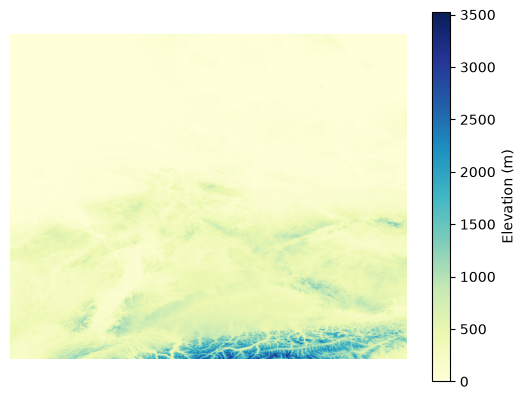

In [ ]:
# Decimated read for display: the full-resolution array would need ~4.5 GB inside imshow.
img, extent = read_preview(dtm_file)

plt.imshow(img, cmap="YlGnBu", extent=extent)
plt.colorbar(label="Elevation (m)")
plt.axis("off")
plt.show()

### Clip to Germany and reproject to EPSG:3857

`rasterio.mask` reads only the window covering Germany (about 70 megapixels). The reprojection
writes straight into a 2000-pixel-wide output and keeps the data as int16 until the very end,
so this cell peaks at a few hundred MB instead of over a gigabyte.

In [ ]:
from rasterio.mask import mask
from rasterio.transform import array_bounds
from rasterio.warp import calculate_default_transform, reproject
from shapely.geometry import mapping

In [ ]:
NODATA = -9999                                   # fits in int16, well below any real elevation
OUT_WIDTH = 2000                                 # output pixels across; plenty for a figure

with rasterio.open(dtm_file) as src:
    germany_geom = gdf_3857.loc[gdf_3857.ADMIN == "Germany"].to_crs(src.crs).geometry
    arr_ma, tr_src = mask(src, [mapping(g) for g in germany_geom], crop=True, filled=False)
    src_band = arr_ma[0].filled(NODATA)          # int16, outside-Germany pixels -> NODATA
    del arr_ma

    h, w = src_band.shape
    left, bottom, right, top = array_bounds(h, w, tr_src)
    tr3857, w3857, h3857 = calculate_default_transform(
        src.crs, "EPSG:3857", w, h, left, bottom, right, top,
        dst_width=OUT_WIDTH, dst_height=int(OUT_WIDTH * h / w),
    )

    dst = np.full((h3857, w3857), NODATA, dtype="int16")
    reproject(src_band, dst, src_transform=tr_src, src_crs=src.crs,
              dst_transform=tr3857, dst_crs="EPSG:3857",
              resampling=Resampling.average, src_nodata=NODATA, dst_nodata=NODATA)
    src_crs = src.crs

del src_band
dst = np.where(dst == NODATA, np.nan, dst.astype("float32"))
print(f"clipped window {h} x {w} px -> reprojected {h3857} x {w3857} px")

clipped window 9354 x 11004 px -> reprojected 1700 x 2000 px


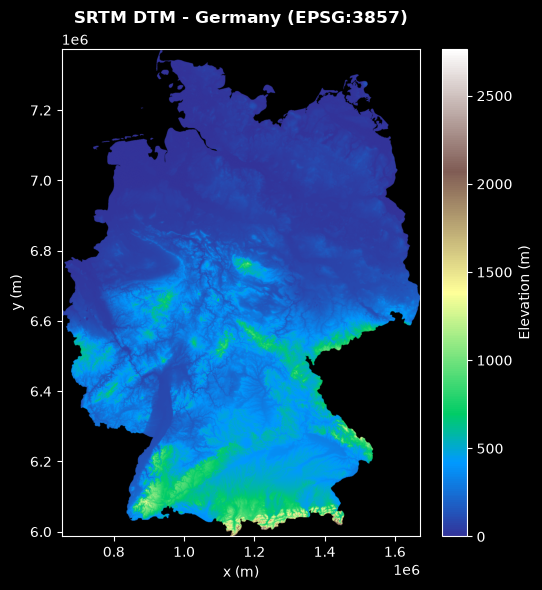

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

xmin, ymin, xmax, ymax = array_bounds(h3857, w3857, tr3857)
im = ax.imshow(dst, extent=(xmin, xmax, ymin, ymax), cmap="terrain", origin="upper")

ax.set_title("SRTM DTM - Germany (EPSG:3857)", color="white", weight="bold", pad=8)
ax.set_xlabel("x (m)", color="white"); ax.set_ylabel("y (m)", color="white")
ax.tick_params(colors="white")
for s in ax.spines.values():
    s.set_color("white")

cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("Elevation (m)", color="white")
cb.ax.tick_params(colors="white")
cb.outline.set_edgecolor("white")

plt.tight_layout()
plt.savefig(FIG / "03_map_raster.png", dpi=150, bbox_inches="tight", facecolor="black")
plt.show()